# Modelagem controlada do risco de defasagem

**Primeira versão exploratória** de um modelo para estimar risco de defasagem no ano seguinte. A saída deve apoiar a priorização de acompanhamento humano e oferta de apoio; não é diagnóstico, decisão automática, ranking ou julgamento de capacidade.

A base possui somente três anos e duas transições (2022 -> 2023 e 2023 -> 2024). Portanto, os resultados são preliminares e não constituem um modelo final ou uma validação temporal robusta.

## 1. Definição do problema preditivo

A pergunta é: **com informações observadas no ano `t`, quais alunos apresentam maior risco agregado de estar em defasagem no ano `t+1`?**

O target provisório é `risco_defasagem = 1` quando `Defasagem(t+1) < 0`. Antes de qualquer treino, o notebook verifica nulos, domínio do IAN e a correspondência empírica entre Defasagem e IAN. A confirmação oficial da regra de negócio continua necessária antes de uso operacional.

In [1]:
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

RAIZ_INICIAL = Path.cwd().resolve()
RAIZ = next(
    (candidato for candidato in (RAIZ_INICIAL, *RAIZ_INICIAL.parents)
     if (candidato / "src" / "carregamento_dados.py").is_file()),
    None,
)
if RAIZ is None:
    raise RuntimeError("Raiz do projeto n?o encontrada. Inicie o Jupyter dentro do reposit?rio.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.carregamento_dados import carregar_base_processada
from src.avaliacao_modelos import (
    avaliar_modelos_ajustados,
    plotar_curvas_precision_recall,
    plotar_matrizes_confusao,
    treinar_e_avaliar_modelos,
)
from src.modelagem import (
    COLUNAS_PROIBIDAS,
    FEATURES_CATEGORICAS,
    FEATURES_NUMERICAS,
    FEATURES_PRINCIPAIS,
    construir_modelos_iniciais,
    construir_preprocessador,
    criar_pares_temporais,
    separar_matriz_target,
    validar_target_defasagem,
)

PASTA_TABELAS = RAIZ / 'reports/tables'
PASTA_FIGURAS = RAIZ / 'reports/figures'
PASTA_TABELAS.mkdir(parents=True, exist_ok=True)
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

versoes = {
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'scikit-learn': sklearn.__version__,
}
versoes

{'Python': '3.13.5',
 'pandas': '2.2.3',
 'numpy': '2.1.3',
 'scikit-learn': '1.6.1'}

## 2. Carregamento da base longitudinal

Usamos a base longitudinal já produzida pela preparação da EDA, sem sobrescrevê-la. A base transversal de 2024 não é suficiente para o desenho temporal.

In [2]:
df = carregar_base_processada()
df['RA'] = df['RA'].astype(str).str.strip()

diagnostico_base = pd.DataFrame({
    'registros': df.groupby('Ano_Referencia').size(),
    'alunos_unicos': df.groupby('Ano_Referencia')['RA'].nunique(),
    'duplicados_ra_ano': [
        df.loc[df['Ano_Referencia'].eq(ano)].duplicated('RA').sum()
        for ano in sorted(df['Ano_Referencia'].unique())
    ],
})
print(f'Dimens?o total: {df.shape[0]} linhas e {df.shape[1]} colunas')
print(f'Alunos ?nicos: {df["RA"].nunique()}')
display(diagnostico_base)

Dimens?o total: 2845 linhas e 30 colunas
Alunos ?nicos: 1586


,registros,alunos_unicos,duplicados_ra_ano
Ano_Referencia,,,
2022,860,860,0
2023,931,931,0
2024,1054,1054,0


## 3. Validação do target

A execução é interrompida se houver target nulo, IAN fora do domínio esperado ou inconsistência na regra observada. A correspondência abaixo é uma validação estrutural da base, não confirmação oficial da semântica.

In [3]:
relatorio_target = validar_target_defasagem(df)
display(pd.Series(relatorio_target, name='resultado').to_frame())
display(pd.crosstab(df['Defasagem'], df['IAN'], margins=True))

if relatorio_target['nulos_defasagem'] > 0:
    raise ValueError('Modelagem bloqueada: há valores nulos em Defasagem.')
if relatorio_target['nulos_ian'] > 0:
    raise ValueError('Modelagem bloqueada: há valores nulos em IAN.')
if not relatorio_target['dominio_ian_valido']:
    raise ValueError('Modelagem bloqueada: o domínio do IAN é inválido.')
if relatorio_target['inconsistencias_defasagem_ian'] > 0:
    raise ValueError('Modelagem bloqueada: Defasagem e IAN são inconsistentes.')

print('Validação estrutural aprovada.')

,resultado
registros,2845
nulos_defasagem,0
nulos_ian,0
inconsistencias_defasagem_ian,0
dominio_ian_valido,True


IAN,2.5,5.0,10.0,All
Defasagem,,,,
-5,1,0,0,1
-4,5,0,0,5
-3,38,0,0,38
-2,0,382,0,382
-1,0,1253,0,1253
0,0,0,1024,1024
1,0,0,120,120
2,0,0,20,20
3,0,0,2,2


Validação estrutural aprovada.


## 4. Criação da variável de risco

A variável é criada somente na linha do ano futuro após a junção por RA:

`risco_defasagem(t+1) = 1` se `Defasagem(t+1) < 0`; caso contrário, `0`.

Nenhuma versão de Defasagem, IAN, Fase Ideal, INDE ou Pedra é usada como feature no modelo principal.

## 5. Features permitidas e proibidas

A primeira versão usa indicadores do ano anterior, fase, idade e tempo no programa. Fase e idade podem funcionar como proxies do estado corrente de defasagem; por isso sua contribuição deve ser tratada como associação preditiva e revista em análise de sensibilidade.

Gênero, instituição e escola ficam fora do modelo principal por exigirem justificativa ética específica. IPP fica fora porque não existe em 2022. Inglês fica fora devido à ausência estrutural elevada. RA é usado somente para criar pares e nunca entra na matriz de modelagem.

In [4]:
catalogo = pd.DataFrame({
    'grupo': ['permitida'] * len(FEATURES_PRINCIPAIS) + ['não permitida'] * len(COLUNAS_PROIBIDAS),
    'coluna': FEATURES_PRINCIPAIS + sorted(COLUNAS_PROIBIDAS),
})
display(catalogo)

,grupo,coluna
0,permitida,Idade
1,permitida,Tempo_no_programa
2,permitida,IAA
3,permitida,IEG
4,permitida,IPS
5,permitida,IDA
6,permitida,Nota_Matematica
7,permitida,Nota_Portugues
8,permitida,IPV
9,permitida,Fase


## 6. Construção das janelas temporais

O treino usa features de 2022 e target de 2023. O teste final usa features de 2023 e target de 2024. Não há divisão aleatória.

In [5]:
treino = criar_pares_temporais(df, ano_features=2022, ano_target=2023)
teste = criar_pares_temporais(df, ano_features=2023, ano_target=2024)

resumo_janelas = pd.DataFrame({
    'janela': ['2022→2023 (treino)', '2023→2024 (teste)'],
    'pares': [len(treino), len(teste)],
    'casos_de_risco': [treino['risco_defasagem'].sum(), teste['risco_defasagem'].sum()],
    'prevalencia_risco': [treino['risco_defasagem'].mean(), teste['risco_defasagem'].mean()],
}).set_index('janela')

alunos_em_ambas = treino['RA'].isin(teste['RA']).sum()
alunos_novos_teste = (~teste['RA'].isin(treino['RA'])).sum()
display(resumo_janelas.style.format({'prevalencia_risco': '{:.1%}'}))
print(f'Alunos em ambas as janelas: {alunos_em_ambas}')
print(f'Alunos não observados na janela de treino: {alunos_novos_teste}')

,pares,casos_de_risco,prevalencia_risco
janela,,,
2022→2023 (treino),570,362,63.5%
2023→2024 (teste),678,305,45.0%


Alunos em ambas as janelas: 434
Alunos não observados na janela de treino: 244


In [6]:
controles_pares = pd.DataFrame({
    'janela': ['2022→2023 (treino)', '2023→2024 (teste)'],
    'pares': [len(treino), len(teste)],
    'chaves_aluno_duplicadas': [
        treino.duplicated('RA').sum(),
        teste.duplicated('RA').sum(),
    ],
    'target_ausente': [
        treino['risco_defasagem'].isna().sum(),
        teste['risco_defasagem'].isna().sum(),
    ],
}).set_index('janela')
display(controles_pares)
print('Controles agregados concluídos; nenhum identificador individual é exibido.')

,pares,chaves_aluno_duplicadas,target_ausente
janela,,,
2022→2023 (treino),570,0,0
2023→2024 (teste),678,0,0


Controles agregados concluídos; nenhum identificador individual é exibido.


In [7]:
distribuicao_target = pd.DataFrame({
    'janela': ['2022→2023 (treino)', '2023→2024 (teste)'],
    'sem_risco': [
        treino['risco_defasagem'].eq(0).sum(),
        teste['risco_defasagem'].eq(0).sum(),
    ],
    'com_risco': [
        treino['risco_defasagem'].eq(1).sum(),
        teste['risco_defasagem'].eq(1).sum(),
    ],
    'prevalencia_risco': [
        treino['risco_defasagem'].mean(),
        teste['risco_defasagem'].mean(),
    ],
}).set_index('janela')
display(distribuicao_target.style.format({'prevalencia_risco': '{:.1%}'}))

,sem_risco,com_risco,prevalencia_risco
janela,,,
2022→2023 (treino),208,362,63.5%
2023→2024 (teste),373,305,45.0%


## 7. Tratamento de nulos e encoding

Variáveis numéricas recebem mediana calculada somente no treino, indicador de ausência e padronização. A variável categórica Fase recebe a moda do treino e one-hot encoding com categorias desconhecidas ignoradas. Todas as transformações ficam dentro de `Pipeline`, impedindo ajuste no teste.

In [8]:
x_treino, y_treino = separar_matriz_target(treino)
x_teste, y_teste = separar_matriz_target(teste)

nulos = pd.DataFrame({
    'nulos_treino': x_treino.isna().sum(),
    'percentual_treino': x_treino.isna().mean(),
    'nulos_teste': x_teste.isna().sum(),
    'percentual_teste': x_teste.isna().mean(),
})
display(nulos.style.format({'percentual_treino': '{:.1%}', 'percentual_teste': '{:.1%}'}))

assert 'RA' not in x_treino.columns
assert set(x_treino.columns) == set(FEATURES_NUMERICAS + FEATURES_CATEGORICAS)

,nulos_treino,percentual_treino,nulos_teste,percentual_teste
Idade,0,0.0%,0,0.0%
Tempo_no_programa,0,0.0%,0,0.0%
IAA,0,0.0%,0,0.0%
IEG,0,0.0%,0,0.0%
IPS,0,0.0%,0,0.0%
IDA,0,0.0%,0,0.0%
Nota_Matematica,0,0.0%,0,0.0%
Nota_Portugues,0,0.0%,0,0.0%
IPV,0,0.0%,0,0.0%
Fase,0,0.0%,0,0.0%


## 8. Decisão metodológica: por que não utilizar Deep Learning

Deep Learning foi considerado, mas não é a abordagem mais adequada para esta versão do projeto. A base contém **2.845 registros longitudinais de 1.586 alunos**, distribuídos em apenas três anos (2022, 2023 e 2024). Isso gera somente duas transições temporais e uma única janela efetiva de teste, o que limita o treinamento e a validação estável de redes neurais e aumenta o risco de sobreajuste. Com uma única janela, também não seria possível verificar de forma robusta se um eventual ganho se mantém entre diferentes safras.

A matriz de modelagem possui poucas features e é predominantemente tabular. Não há imagens, textos, áudios ou sequências extensas, nem necessidade clara de aprendizado automático de representações complexas. Modelos tabulares regularizados e baseados em árvores são mais adequados à estrutura disponível, já apresentam sinal preditivo relevante e permitem uma avaliação mais defensável com o volume atual.

No contexto educacional, explicabilidade, auditoria e supervisão humana são requisitos centrais. Redes neurais aumentariam a dificuldade de explicar sinalizações e auditar o comportamento do modelo, além de elevar o custo de ajuste, monitoramento e manutenção, sem benefício proporcional demonstrável nesta base. Esta é, portanto, uma **decisão técnica e contextual**, e não desconhecimento da abordagem ou limitação meramente computacional.

Deep Learning poderá ser reconsiderado quando houver mais alunos e ciclos, múltiplas janelas temporais independentes e maior complexidade informacional, como textos, imagens, áudios ou sequências longitudinais extensas. Uma futura adoção deverá demonstrar ganho consistente sobre os modelos tabulares e preservar explicabilidade suficiente para apoiar a revisão humana.

## 9. Baseline e modelos iniciais

O `DummyClassifier` representa a referência baseada na prevalência. Os demais modelos são configurações iniciais conservadoras, sem busca de hiperparâmetros no teste:

- LogisticRegression;
- DecisionTreeClassifier;
- RandomForestClassifier;
- GradientBoostingClassifier.

,recall_risco,precision_risco,f1_risco,pr_auc,brier_score
modelo,,,,,
LogisticRegression,0.521,0.841,0.644,0.809,0.179
RandomForestClassifier,0.675,0.746,0.709,0.800,0.173
GradientBoostingClassifier,0.669,0.726,0.696,0.781,0.178
DecisionTreeClassifier,0.564,0.778,0.654,0.747,0.185
DummyClassifier,1.000,0.450,0.621,0.450,0.282


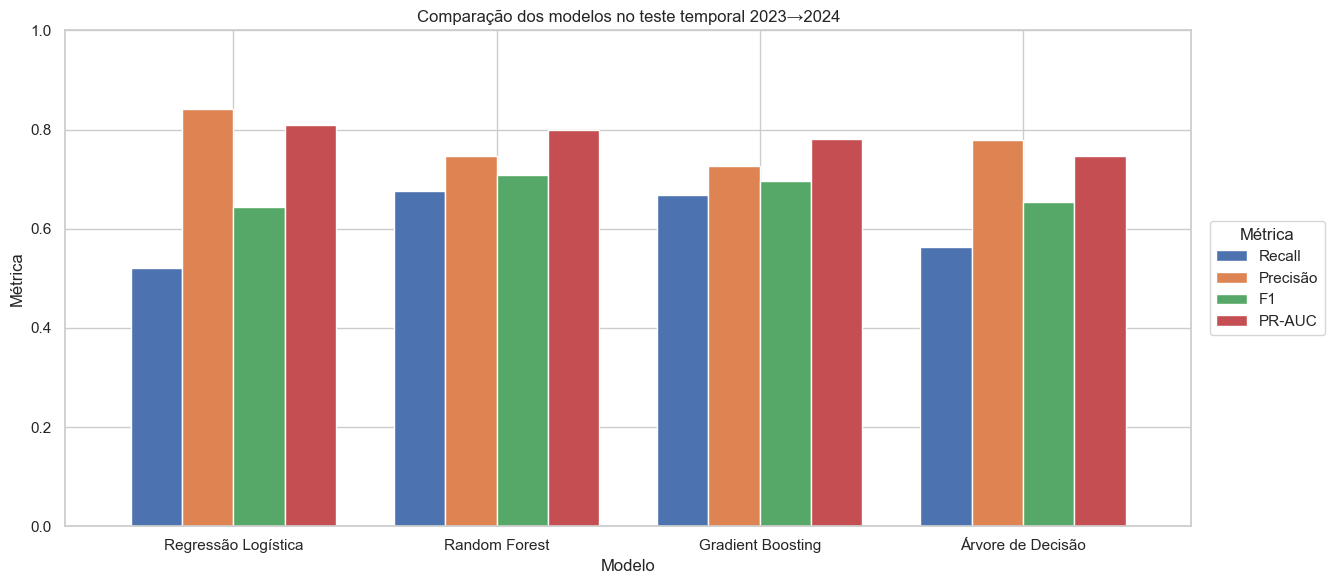

In [9]:
modelos = construir_modelos_iniciais()
comparacao, matrizes, modelos_ajustados = treinar_e_avaliar_modelos(
    modelos, x_treino, y_treino, x_teste, y_teste
)

metricas_exportacao = comparacao.reset_index()
metricas_exportacao.to_csv(
    PASTA_TABELAS / 'model_metrics.csv', index=False, encoding='utf-8-sig'
)

display(
    comparacao
    .style
    .format('{:.3f}')
    .background_gradient(
        cmap='Blues',
        subset=['recall_risco', 'precision_risco', 'f1_risco', 'pr_auc']
    )
    .background_gradient(cmap='Blues_r', subset=['brier_score'])
)

metricas_grafico = (
    comparacao.drop(index='DummyClassifier')
    [['recall_risco', 'precision_risco', 'f1_risco', 'pr_auc']]
    .rename(columns={
        'recall_risco': 'Recall',
        'precision_risco': 'Precisão',
        'f1_risco': 'F1',
        'pr_auc': 'PR-AUC',
    })
)
figura, eixo = plt.subplots(figsize=(13.5, 6))
metricas_grafico.plot(kind='bar', ax=eixo, width=0.78)
eixo.set_xticklabels([
    'Regressão Logística', 'Random Forest',
    'Gradient Boosting', 'Árvore de Decisão'
])
eixo.set_title('Comparação dos modelos no teste temporal 2023→2024')
eixo.set_xlabel('Modelo')
eixo.set_ylabel('Métrica')
eixo.set_ylim(0, 1)
eixo.tick_params(axis='x', rotation=0)
eixo.legend(title='Métrica', loc='center left', bbox_to_anchor=(1.01, 0.5))
figura.tight_layout()
figura.savefig(PASTA_FIGURAS / 'comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Matrizes de confusão e curvas precisão-recall

Falsos negativos representam alunos em risco não sinalizados. Falsos positivos representam sinalizações que exigiriam revisão humana, com possibilidade de estigma ou uso inadequado. Nenhuma matriz contém identificação individual.

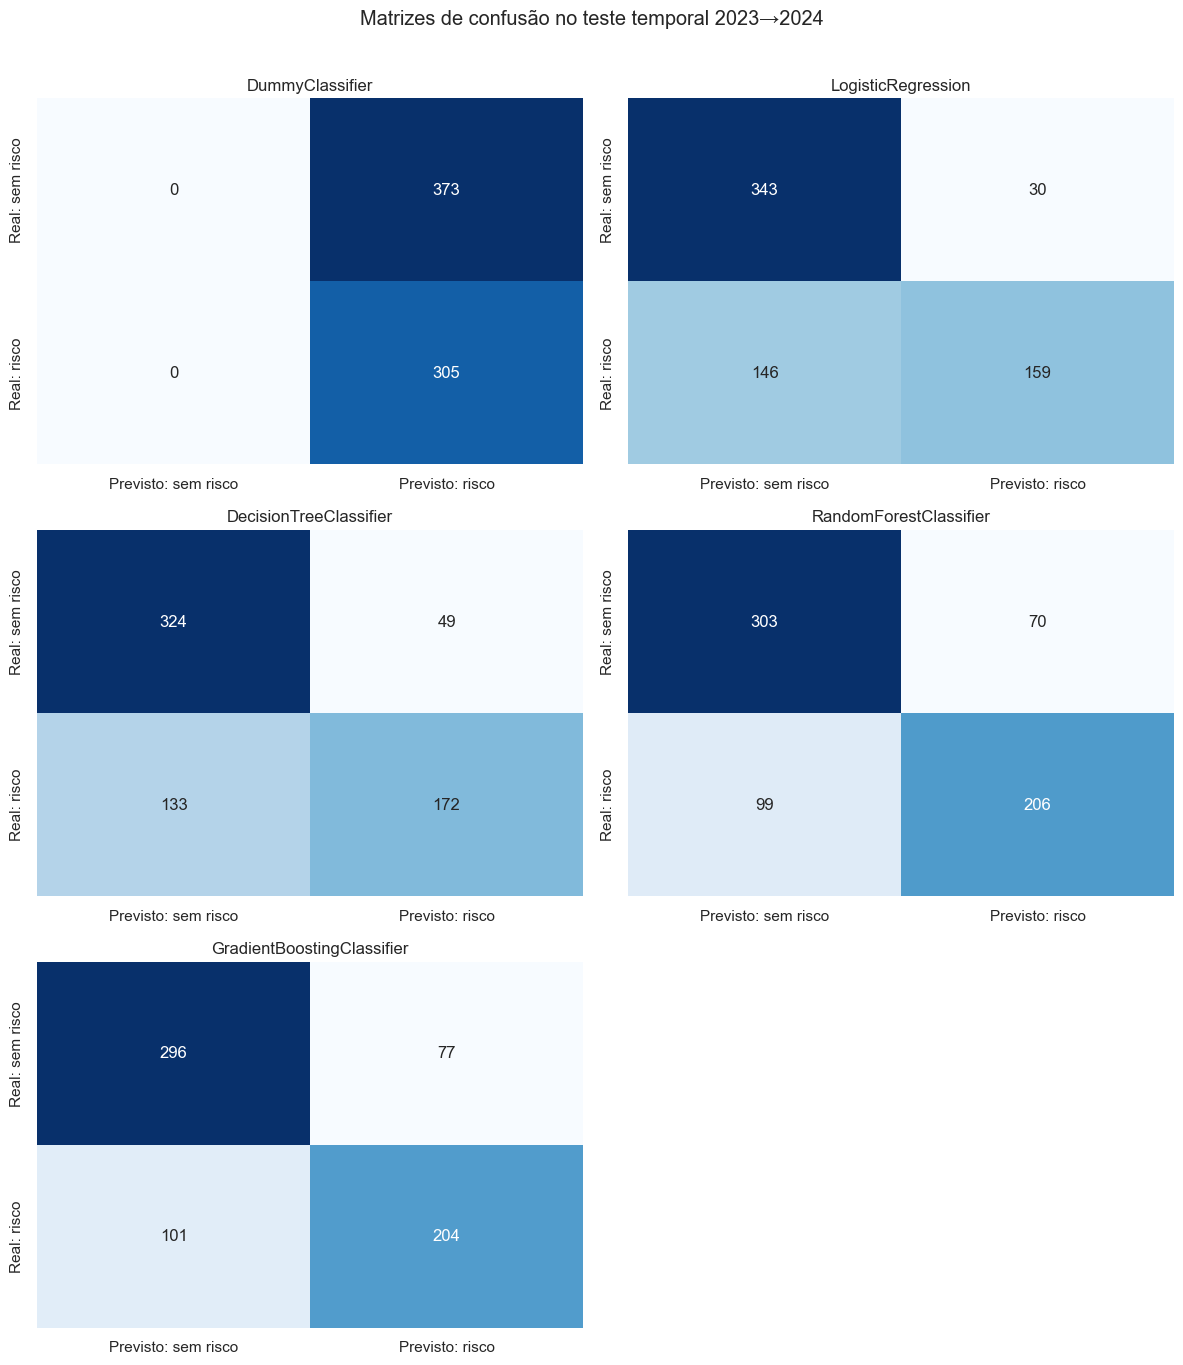

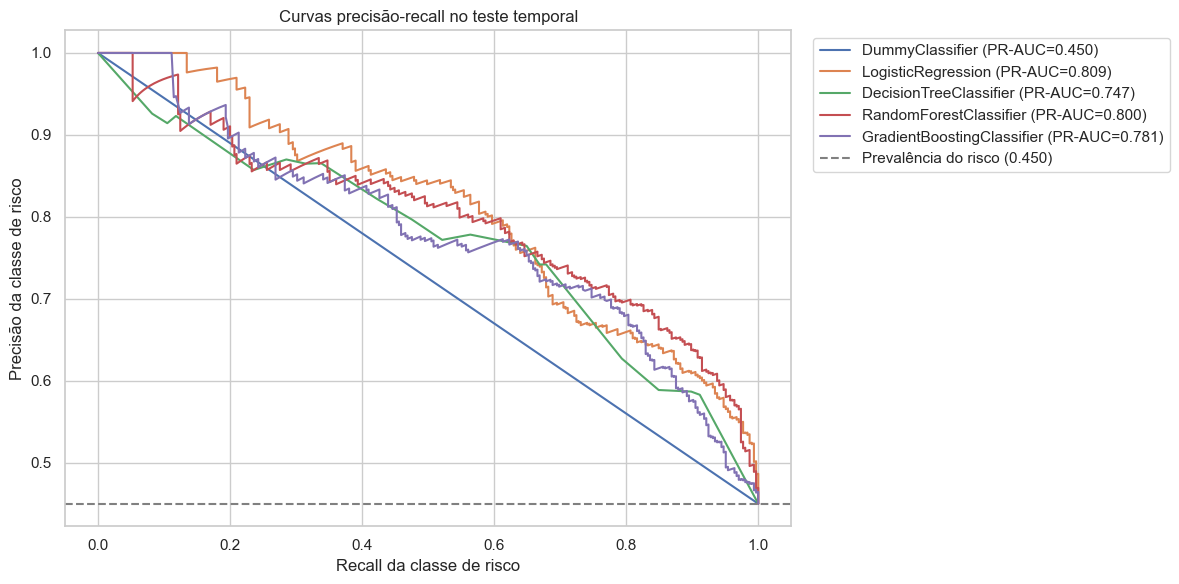

In [10]:
plotar_matrizes_confusao(matrizes)
plt.show()
plotar_curvas_precision_recall(modelos_ajustados, x_teste, y_teste)
plt.show()

## 11. Análise exploratória de limiares do Random Forest

O limiar de 0,50 é apenas uma referência técnica. Como o objetivo é apoiar acompanhamento preventivo, avaliamos limiares alternativos priorizando a redução de falsos negativos. A contrapartida é o aumento de falsos positivos, que também exige atenção por consumir capacidade de acompanhamento e poder gerar estigmatização.

Para tornar a escolha reproduzível, adotamos um **critério exploratório**, e não operacional: entre os limiares com recall superior ao obtido em 0,50 e precision de pelo menos 0,65, selecionamos aquele com maior recall. Esse piso é apenas uma salvaguarda analítica nesta amostra; não representa requisito de negócio aprovado. Como a escolha observa a única janela de teste disponível, seu desempenho é otimista e precisa ser reavaliado em novas safras.

In [11]:
modelo_rf = modelos_ajustados['RandomForestClassifier']
probabilidades_rf = modelo_rf.predict_proba(x_teste)[:, 1]

limiares = np.round(np.arange(0.20, 0.81, 0.05), 2)
resultados_limiares = []
for limiar in limiares:
    predicoes_limiar = (probabilidades_rf >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_teste, predicoes_limiar, labels=[0, 1]
    ).ravel()
    resultados_limiares.append({
        'limiar': limiar,
        'recall_risco': recall_score(y_teste, predicoes_limiar, zero_division=0),
        'precision_risco': precision_score(y_teste, predicoes_limiar, zero_division=0),
        'f1_risco': f1_score(y_teste, predicoes_limiar, zero_division=0),
        'sinalizados': int(predicoes_limiar.sum()),
        'proporcao_sinalizada': float(predicoes_limiar.mean()),
        'verdadeiros_negativos': int(tn),
        'falsos_positivos': int(fp),
        'falsos_negativos': int(fn),
        'verdadeiros_positivos': int(tp),
    })

analise_limiares = pd.DataFrame(resultados_limiares)
referencia_050 = analise_limiares.loc[
    analise_limiares['limiar'].eq(0.50)
].iloc[0]
analise_limiares['delta_recall_vs_0_50'] = (
    analise_limiares['recall_risco'] - referencia_050['recall_risco']
)
analise_limiares['delta_precision_vs_0_50'] = (
    analise_limiares['precision_risco'] - referencia_050['precision_risco']
)

piso_precision_exploratorio = 0.65
candidatos_limiar = analise_limiares.loc[
    analise_limiares['recall_risco'].gt(referencia_050['recall_risco'])
    & analise_limiares['precision_risco'].ge(piso_precision_exploratorio)
]
if candidatos_limiar.empty:
    raise ValueError('Nenhum limiar atende ao critério exploratório declarado.')

linha_limiar_alternativo = candidatos_limiar.sort_values(
    ['recall_risco', 'precision_risco'], ascending=False
).iloc[0]
limiar_alternativo = float(linha_limiar_alternativo['limiar'])

analise_limiares.to_csv(
    PASTA_TABELAS / 'threshold_analysis_random_forest.csv',
    index=False,
    encoding='utf-8-sig',
)
display(
    analise_limiares.style.format({
        'limiar': '{:.2f}',
        'recall_risco': '{:.3f}',
        'precision_risco': '{:.3f}',
        'f1_risco': '{:.3f}',
        'proporcao_sinalizada': '{:.1%}',
        'delta_recall_vs_0_50': '{:+.3f}',
        'delta_precision_vs_0_50': '{:+.3f}',
    })
)

print(f'Limiar exploratório sugerido: {limiar_alternativo:.2f}.')
print(
    f'Recall: {referencia_050["recall_risco"]:.3f} → '
    f'{linha_limiar_alternativo["recall_risco"]:.3f} '
    f'(Δ={linha_limiar_alternativo["delta_recall_vs_0_50"]:+.3f}).'
)
print(
    f'Precisão: {referencia_050["precision_risco"]:.3f} → '
    f'{linha_limiar_alternativo["precision_risco"]:.3f} '
    f'(Δ={linha_limiar_alternativo["delta_precision_vs_0_50"]:+.3f}).'
)
print('Este limiar não está aprovado para uso operacional.')

,limiar,recall_risco,precision_risco,f1_risco,sinalizados,proporcao_sinalizada,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos,delta_recall_vs_0_50,delta_precision_vs_0_50
0,0.20,0.993,0.493,0.659,615,90.7%,61,312,2,303,+0.318,-0.254
1,0.25,0.974,0.527,0.684,564,83.2%,106,267,8,297,+0.298,-0.220
2,0.30,0.948,0.595,0.731,486,71.7%,176,197,16,289,+0.272,-0.152
3,0.35,0.889,0.644,0.747,421,62.1%,223,150,34,271,+0.213,-0.103
4,0.40,0.839,0.684,0.754,374,55.2%,255,118,49,256,+0.164,-0.062
5,0.45,0.770,0.714,0.741,329,48.5%,279,94,70,235,+0.095,-0.032
6,0.50,0.675,0.746,0.709,276,40.7%,303,70,99,206,+0.000,+0.000
7,0.55,0.587,0.796,0.675,225,33.2%,327,46,126,179,-0.089,+0.049
8,0.60,0.479,0.820,0.605,178,26.3%,341,32,159,146,-0.197,+0.074
9,0.65,0.387,0.849,0.532,139,20.5%,352,21,187,118,-0.289,+0.103


Limiar exploratório sugerido: 0.40.
Recall: 0.675 → 0.839 (Δ=+0.164).
Precisão: 0.746 → 0.684 (Δ=-0.062).
Este limiar não está aprovado para uso operacional.


## 12. Matrizes de confusão e curva precision-recall do Random Forest

As matrizes tornam explícita a troca entre falsos negativos e falsos positivos. A curva precision-recall resume o comportamento do Random Forest ao longo de todos os limiares. Nenhum gráfico contém identificação ou previsão individual.

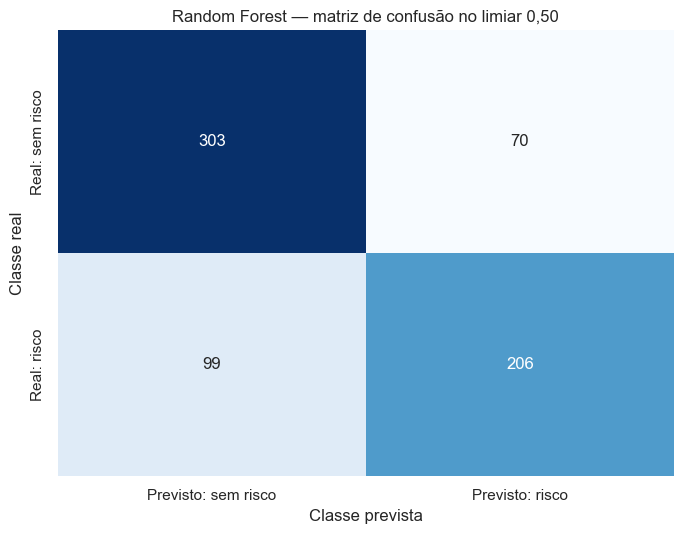

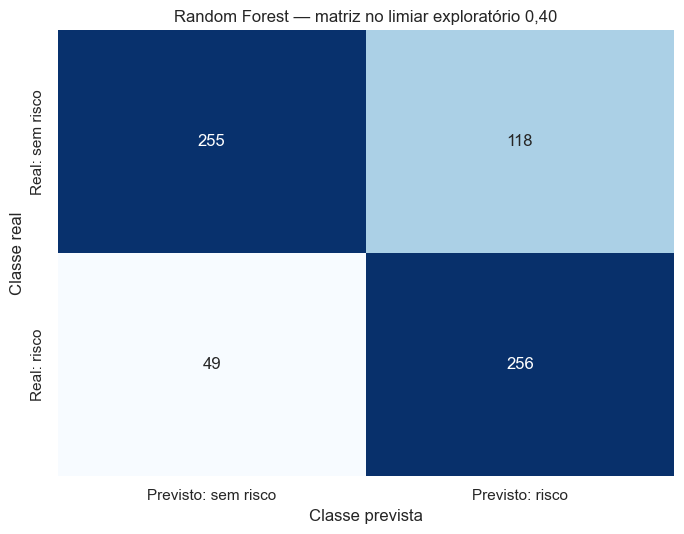

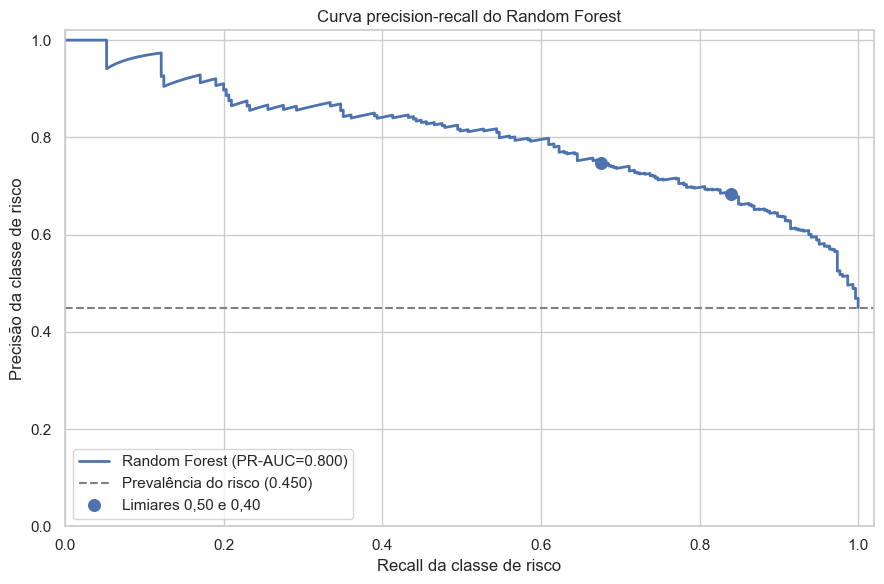

In [12]:
def salvar_matriz_rf(predicoes, titulo, nome_arquivo):
    matriz = confusion_matrix(y_teste, predicoes, labels=[0, 1])
    tabela_matriz = pd.DataFrame(
        matriz,
        index=['Real: sem risco', 'Real: risco'],
        columns=['Previsto: sem risco', 'Previsto: risco'],
    )
    figura, eixo = plt.subplots(figsize=(7, 5.5))
    sns.heatmap(tabela_matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=eixo)
    eixo.set_title(titulo)
    eixo.set_xlabel('Classe prevista')
    eixo.set_ylabel('Classe real')
    figura.tight_layout()
    figura.savefig(PASTA_FIGURAS / nome_arquivo, dpi=180, bbox_inches='tight')
    plt.show()
    return tabela_matriz

predicoes_rf_050 = (probabilidades_rf >= 0.50).astype(int)
predicoes_rf_alternativo = (probabilidades_rf >= limiar_alternativo).astype(int)

matriz_rf_050 = salvar_matriz_rf(
    predicoes_rf_050,
    'Random Forest — matriz de confusão no limiar 0,50',
    'matriz_confusao_random_forest.png',
)
matriz_rf_alternativo = salvar_matriz_rf(
    predicoes_rf_alternativo,
    f'Random Forest — matriz no limiar exploratório {limiar_alternativo:.2f}'.replace('.', ','),
    'matriz_confusao_random_forest_limiar_alternativo.png',
)

precisoes_curva, recalls_curva, _ = precision_recall_curve(
    y_teste, probabilidades_rf
)
pr_auc_rf = average_precision_score(y_teste, probabilidades_rf)
figura, eixo = plt.subplots(figsize=(9, 6))
eixo.plot(recalls_curva, precisoes_curva, linewidth=2, label=f'Random Forest (PR-AUC={pr_auc_rf:.3f})')
eixo.axhline(
    y_teste.mean(), color='gray', linestyle='--',
    label=f'Prevalência do risco ({y_teste.mean():.3f})'
)
eixo.scatter(
    [referencia_050['recall_risco'], linha_limiar_alternativo['recall_risco']],
    [referencia_050['precision_risco'], linha_limiar_alternativo['precision_risco']],
    s=70,
    zorder=3,
    label=f'Limiares 0,50 e {limiar_alternativo:.2f}'.replace('.', ','),
)
eixo.set_title('Curva precision-recall do Random Forest')
eixo.set_xlabel('Recall da classe de risco')
eixo.set_ylabel('Precisão da classe de risco')
eixo.set_xlim(0, 1.02)
eixo.set_ylim(0, 1.02)
eixo.legend(loc='lower left')
figura.tight_layout()
figura.savefig(
    PASTA_FIGURAS / 'curva_precision_recall_random_forest.png',
    dpi=180,
    bbox_inches='tight',
)
plt.show()

## 13. Sensibilidade para alunos não observados no treino

Como parte dos alunos aparece nas duas janelas, avaliamos separadamente os registros de 2024 cujos RAs não participaram da janela 2022→2023. O RA serve apenas para construir a máscara; não é fornecido aos modelos.

In [13]:
mascara_nao_observados = ~teste['RA'].isin(treino['RA'])
comparacao_nao_observados = avaliar_modelos_ajustados(
    modelos_ajustados,
    x_teste.loc[mascara_nao_observados],
    y_teste.loc[mascara_nao_observados],
)
print(f'Amostra de sensibilidade: {mascara_nao_observados.sum()} alunos')
display(comparacao_nao_observados.style.format('{:.3f}'))

Amostra de sensibilidade: 244 alunos


,recall_risco,precision_risco,f1_risco,pr_auc,brier_score
modelo,,,,,
LogisticRegression,0.448,0.901,0.598,0.842,0.240
RandomForestClassifier,0.657,0.797,0.720,0.836,0.198
DecisionTreeClassifier,0.462,0.846,0.597,0.817,0.226
GradientBoostingClassifier,0.566,0.764,0.651,0.794,0.230
DummyClassifier,1.000,0.586,0.739,0.586,0.245


## 14. Explicabilidade global inicial

A tabela mostra os maiores coeficientes absolutos da regressão logística e as maiores importâncias dos modelos de árvore. Essas medidas descrevem o comportamento do modelo e **não demonstram causalidade**, mérito ou capacidade individual.

In [14]:
explicacoes = {}
for nome, pipeline in modelos_ajustados.items():
    if nome == 'DummyClassifier':
        continue
    nomes_features = pipeline.named_steps['preprocessamento'].get_feature_names_out()
    estimador = pipeline.named_steps['modelo']
    if hasattr(estimador, 'coef_'):
        valores = estimador.coef_[0]
        tabela = pd.DataFrame({'feature': nomes_features, 'valor': valores})
        tabela['importancia_absoluta'] = tabela['valor'].abs()
    else:
        valores = estimador.feature_importances_
        tabela = pd.DataFrame({'feature': nomes_features, 'valor': valores})
        tabela['importancia_absoluta'] = tabela['valor'].abs()
    explicacoes[nome] = tabela.nlargest(10, 'importancia_absoluta').reset_index(drop=True)

for nome, tabela in explicacoes.items():
    print(f'\n{nome}')
    display(tabela)


LogisticRegression


,feature,valor,importancia_absoluta
0,Fase_ALFA,4.274590,4.274590
1,Fase_FASE 6,-2.321300,2.321300
2,Fase_FASE 1,2.276861,2.276861
3,Idade,2.262929,2.262929
4,Fase_FASE 3,-1.810378,1.810378
5,Fase_FASE 5,-1.311251,1.311251
6,Fase_FASE 4,-1.198200,1.198200
7,IDA,-0.895736,0.895736
8,IPV,-0.693397,0.693397
9,Nota_Portugues,0.315128,0.315128



DecisionTreeClassifier


,feature,valor,importancia_absoluta
0,IPV,0.332877,0.332877
1,Idade,0.322471,0.322471
2,Fase_ALFA,0.116985,0.116985
3,Nota_Matematica,0.051412,0.051412
4,Fase_FASE 1,0.045837,0.045837
5,Nota_Portugues,0.037410,0.037410
6,Fase_FASE 3,0.036577,0.036577
7,IDA,0.020273,0.020273
8,IAA,0.019326,0.019326
9,IEG,0.016833,0.016833



RandomForestClassifier


,feature,valor,importancia_absoluta
0,IPV,0.210588,0.210588
1,Idade,0.150700,0.150700
2,IDA,0.104853,0.104853
3,Nota_Matematica,0.090237,0.090237
4,IEG,0.088528,0.088528
5,Nota_Portugues,0.081548,0.081548
6,Fase_ALFA,0.070630,0.070630
7,Fase_FASE 3,0.044071,0.044071
8,IAA,0.042114,0.042114
9,Tempo_no_programa,0.039945,0.039945



GradientBoostingClassifier


,feature,valor,importancia_absoluta
0,Idade,0.283342,0.283342
1,IPV,0.195219,0.195219
2,Fase_ALFA,0.102098,0.102098
3,Fase_FASE 3,0.084151,0.084151
4,IDA,0.053577,0.053577
5,Nota_Matematica,0.046699,0.046699
6,Fase_FASE 2,0.041812,0.041812
7,Nota_Portugues,0.039784,0.039784
8,IAA,0.027873,0.027873
9,IPS,0.027058,0.027058


## 15. Sensibilidade sem Fase e Idade

`Fase` e `Idade` podem funcionar como proxies do estado corrente de defasagem. Para avaliar a dependência dos resultados em relação a essas variáveis, repetimos exatamente o mesmo desenho temporal e as mesmas configurações dos estimadores, retirando ambas as features.

Esta análise mede sensibilidade preditiva. Uma perda de desempenho sugere que os modelos utilizavam informação relevante presente nessas variáveis, mas não demonstra causalidade nem prova que as demais features estejam livres de proxies.

In [15]:
features_numericas_sem_fase_idade = [
    coluna for coluna in FEATURES_NUMERICAS if coluna != 'Idade'
]
features_sem_fase_idade = features_numericas_sem_fase_idade.copy()

x_treino_sem_fase_idade = x_treino[features_sem_fase_idade].copy()
x_teste_sem_fase_idade = x_teste[features_sem_fase_idade].copy()

assert 'RA' not in x_treino_sem_fase_idade.columns
assert 'Fase' not in x_treino_sem_fase_idade.columns
assert 'Idade' not in x_treino_sem_fase_idade.columns

modelos_sem_fase_idade = construir_modelos_iniciais()
for pipeline in modelos_sem_fase_idade.values():
    pipeline.set_params(
        preprocessamento=construir_preprocessador(
            features_numericas=features_numericas_sem_fase_idade,
            features_categoricas=[],
        )
    )

comparacao_sem_fase_idade, _, modelos_ajustados_sem_fase_idade = treinar_e_avaliar_modelos(
    modelos_sem_fase_idade,
    x_treino_sem_fase_idade,
    y_treino,
    x_teste_sem_fase_idade,
    y_teste,
)

metricas_comparadas = comparacao.add_prefix('principal_').join(
    comparacao_sem_fase_idade.add_prefix('sem_fase_idade_'), how='inner'
)
for metrica in ['recall_risco', 'precision_risco', 'f1_risco', 'pr_auc', 'brier_score']:
    metricas_comparadas[f'delta_{metrica}'] = (
        metricas_comparadas[f'sem_fase_idade_{metrica}']
        - metricas_comparadas[f'principal_{metrica}']
    )

metricas_comparadas.reset_index().to_csv(
    PASTA_TABELAS / 'model_metrics_sem_fase_idade.csv',
    index=False,
    encoding='utf-8-sig',
)
display(metricas_comparadas.style.format('{:.3f}'))

sensibilidade_rf = metricas_comparadas.loc['RandomForestClassifier']
queda_relevante = (
    sensibilidade_rf['delta_recall_risco'] <= -0.10
    or sensibilidade_rf['delta_pr_auc'] <= -0.05
)
print(
    'Random Forest — variação sem Fase/Idade: '
    f'recall {sensibilidade_rf["delta_recall_risco"]:+.3f}; '
    f'precision {sensibilidade_rf["delta_precision_risco"]:+.3f}; '
    f'F1 {sensibilidade_rf["delta_f1_risco"]:+.3f}; '
    f'PR-AUC {sensibilidade_rf["delta_pr_auc"]:+.3f}; '
    f'Brier {sensibilidade_rf["delta_brier_score"]:+.3f}.'
)
if queda_relevante:
    print(
        'Houve perda preditiva relevante sem Fase e Idade. Isso reforça o risco de proxy '
        'e a necessidade de revisão ética e validação externa; não autoriza interpretação causal.'
    )
else:
    print(
        'Não houve perda preditiva relevante pelos critérios exploratórios adotados, '
        'mas o risco de proxy nas demais variáveis permanece.'
    )

,principal_recall_risco,principal_precision_risco,principal_f1_risco,principal_pr_auc,principal_brier_score,sem_fase_idade_recall_risco,sem_fase_idade_precision_risco,sem_fase_idade_f1_risco,sem_fase_idade_pr_auc,sem_fase_idade_brier_score,delta_recall_risco,delta_precision_risco,delta_f1_risco,delta_pr_auc,delta_brier_score
modelo,,,,,,,,,,,,,,,
LogisticRegression,0.521,0.841,0.644,0.809,0.179,0.269,0.759,0.397,0.674,0.228,-0.252,-0.082,-0.247,-0.135,0.049
RandomForestClassifier,0.675,0.746,0.709,0.800,0.173,0.479,0.679,0.562,0.691,0.209,-0.197,-0.067,-0.148,-0.109,0.036
GradientBoostingClassifier,0.669,0.726,0.696,0.781,0.178,0.607,0.562,0.584,0.620,0.231,-0.062,-0.164,-0.113,-0.160,0.053
DecisionTreeClassifier,0.564,0.778,0.654,0.747,0.185,0.249,0.697,0.367,0.616,0.230,-0.315,-0.081,-0.287,-0.131,0.045
DummyClassifier,1.000,0.450,0.621,0.450,0.282,1.000,0.450,0.621,0.450,0.282,0.000,0.000,0.000,0.000,0.000


Random Forest — variação sem Fase/Idade: recall -0.197; precision -0.067; F1 -0.148; PR-AUC -0.109; Brier +0.036.
Houve perda preditiva relevante sem Fase e Idade. Isso reforça o risco de proxy e a necessidade de revisão ética e validação externa; não autoriza interpretação causal.


## 16. Comparação e análise crítica dos resultados

A PR-AUC é a métrica principal de ordenação porque considera o desempenho da classe de risco diante da prevalência observada. Recall, precision, F1 e Brier devem ser lidos em conjunto. O limiar padrão desta execução é apenas uma referência técnica e nenhum limiar foi aprovado para uso operacional.

Como o problema envolve sinalizar alunos em situação potencial de risco, a decisão preliminar precisa considerar o tipo de erro mais sensível para o contexto da Passos Mágicos. Um falso negativo é mais crítico do que um falso positivo porque representa um aluno em risco que não seria sinalizado para acompanhamento preventivo. Falsos positivos, contudo, também têm custos de capacidade, possível estigma e intervenção desnecessária, por isso não podem ser ignorados.

### 16.1. Escolha preliminar do modelo

Embora a Regressão Logística tenha apresentado a maior PR-AUC preliminar, o modelo escolhido para continuidade da análise será o **Random Forest**, pois ele apresentou maior **recall da classe de risco**.

Essa escolha é coerente com o objetivo do projeto: identificar alunos com maior probabilidade de entrar ou permanecer em defasagem para apoiar ações preventivas da Passos Mágicos. Nesse contexto, um falso negativo é mais crítico do que um falso positivo, pois representa um aluno em risco que não seria sinalizado para acompanhamento.

A Regressão Logística teve PR-AUC ligeiramente superior, mas sinalizou uma proporção menor dos alunos em risco. Já o Random Forest apresentou maior recall, melhor F1 e menor Brier score no teste temporal, oferecendo melhor equilíbrio para esta primeira versão exploratória, ainda que com alguma perda de precisão.

Portanto, o Random Forest será tratado como **modelo candidato principal para continuidade**, não como modelo final. O limiar alternativo é somente uma sugestão exploratória. Antes de qualquer uso operacional, ainda será necessário realizar calibração de probabilidades, definição de limiar com critérios de negócio, análise de falsos negativos, validação externa e revisão ética das variáveis utilizadas.

In [16]:
modelos_reais = comparacao.drop(index='DummyClassifier')
melhor_nome = modelos_reais['pr_auc'].idxmax()
melhor = modelos_reais.loc[melhor_nome]
baseline = comparacao.loc['DummyClassifier']
ganho_pr_auc = melhor['pr_auc'] - baseline['pr_auc']

print(f'Melhor PR-AUC preliminar: {melhor_nome} ({melhor["pr_auc"]:.3f}).')
print(f'Ganho absoluto sobre o baseline: {ganho_pr_auc:.3f}.')
print(f'Recall de risco: {melhor["recall_risco"]:.3f}.')
print(f'Precisão de risco: {melhor["precision_risco"]:.3f}.')
print(f'F1 de risco: {melhor["f1_risco"]:.3f}.')

if ganho_pr_auc <= 0:
    print('Os modelos não superaram o baseline em PR-AUC; não há evidência para avanço operacional.')
else:
    print('Há sinal preditivo preliminar, mas ele precisa de novas safras, calibração e validação externa.')

Melhor PR-AUC preliminar: LogisticRegression (0.809).
Ganho absoluto sobre o baseline: 0.359.
Recall de risco: 0.521.
Precisão de risco: 0.841.
F1 de risco: 0.644.
Há sinal preditivo preliminar, mas ele precisa de novas safras, calibração e validação externa.


In [17]:
modelo_escolhido = comparacao.loc['RandomForestClassifier']
modelo_logistico = comparacao.loc['LogisticRegression']

print('Melhor PR-AUC preliminar: LogisticRegression.')
print(f'PR-AUC da Regressão Logística: {modelo_logistico["pr_auc"]:.3f}.')
print('Modelo candidato principal para continuidade: RandomForestClassifier.')
print(f'PR-AUC: {modelo_escolhido["pr_auc"]:.3f}.')
print(f'Recall de risco: {modelo_escolhido["recall_risco"]:.3f}.')
print(f'Precisão de risco: {modelo_escolhido["precision_risco"]:.3f}.')
print(f'F1 de risco: {modelo_escolhido["f1_risco"]:.3f}.')
print(f'Brier score: {modelo_escolhido["brier_score"]:.3f}.')
print(
    'A escolha preliminar prioriza maior recall, melhor F1 e menor Brier score. '
    'Neste problema, deixar de sinalizar um aluno em risco é mais crítico do que '
    'gerar uma sinalização adicional para revisão humana.'
)
print(
    f'O limiar {limiar_alternativo:.2f} é apenas exploratório e não operacional. '
    'O Random Forest não é declarado modelo final.'
)
print(
    'Antes de qualquer uso: calibração, definição de limiar com a área de negócio, '
    'validação externa, análise de falsos negativos e revisão ética.'
)

Melhor PR-AUC preliminar: LogisticRegression.
PR-AUC da Regressão Logística: 0.809.
Modelo candidato principal para continuidade: RandomForestClassifier.
PR-AUC: 0.800.
Recall de risco: 0.675.
Precisão de risco: 0.746.
F1 de risco: 0.709.
Brier score: 0.173.
A escolha preliminar prioriza maior recall, melhor F1 e menor Brier score. Neste problema, deixar de sinalizar um aluno em risco é mais crítico do que gerar uma sinalização adicional para revisão humana.
O limiar 0.40 é apenas exploratório e não operacional. O Random Forest não é declarado modelo final.
Antes de qualquer uso: calibração, definição de limiar com a área de negócio, validação externa, análise de falsos negativos e revisão ética.


## 17. Limitações

1. O target de risco é **provisório**: a regra baseada em `Defasagem(t+1) < 0` foi validada estruturalmente na base, mas ainda exige confirmação formal da regra de negócio.
2. Há somente três anos e duas transições, deixando apenas **uma janela temporal de teste**. Isso impede estimar estabilidade entre safras.
3. A prevalência do risco muda entre treino e teste, indicando possível mudança de população, processo ou distribuição.
4. Parte dos alunos aparece em treino e teste. A sensibilidade para alunos não observados reduz, mas não elimina a dependência longitudinal.
5. `Fase` e `Idade` podem funcionar como **proxies do estado de defasagem**. A perda observada sem essas variáveis reforça a necessidade de revisão, mas não demonstra causalidade.
6. Retirar `Fase` e `Idade` não garante que as demais variáveis estejam livres de proxies.
7. O limiar alternativo foi escolhido observando a única janela de teste; portanto, pode apresentar desempenho otimista e **não está aprovado para uso operacional**.
8. Não houve tuning extensivo, coerentemente com o volume de dados e a única janela temporal disponível.
9. O Brier score oferece uma leitura inicial, mas ainda faltam calibração formal, curvas de calibração e avaliação da estabilidade das probabilidades.
10. Não há validação externa, intervalos de incerteza ou avaliação prospectiva.
11. Importâncias e coeficientes explicam associações utilizadas pelo modelo; não representam efeitos causais, mérito ou capacidade individual.
12. A redução de falsos negativos aumenta sinalizações e falsos positivos, com possíveis custos operacionais e éticos que precisam ser definidos com a Passos Mágicos.
13. Nenhuma previsão deve ser usada para ranking, decisão automática ou restrição de oportunidades.
14. A não utilização de Deep Learning é adequada ao volume, à baixa dimensionalidade, à única janela temporal de teste e à exigência de explicabilidade desta versão. A decisão deve ser reavaliada se a base ganhar escala, novas safras e maior complexidade informacional.

**Conclusão:** esta execução produz somente evidência preliminar para pesquisa e desenvolvimento. Nenhum dos estimadores é declarado modelo final. A priorização de modelos tabulares é uma decisão técnica compatível com os dados e os requisitos atuais; Deep Learning poderá ser reconsiderado quando houver escala, diversidade informacional e validação temporal suficientes para demonstrar benefício consistente e auditável.

## 18. Otimização controlada de hiperparâmetros

O Grid Search é usado para comparar sistematicamente configurações previamente delimitadas das quatro famílias candidatas. A busca recebe **somente** a janela features de 2022 → target de 2023. A janela features de 2023 → target de 2024 permanece isolada durante o tuning e é consultada uma única vez, depois da seleção interna de uma configuração por família. O `DummyClassifier` permanece somente como baseline.

A validação interna usa `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`. O preprocessing aprovado continua dentro do `Pipeline`, sendo ajustado novamente em cada fold. A métrica de refit do `GridSearchCV` é PR-AUC (`average_precision`); recall, precision, F1, Brier, desvios entre folds e diferenças treino–validação são preservados.

Os grids contêm 50 configurações de Regressão Logística, 360 de Árvore de Decisão, 432 de Random Forest e 162 de Gradient Boosting: 1.004 configurações, 5.020 fits de validação e quatro refits por PR-AUC, totalizando 5.024 ajustes do Grid Search. A busca cobre os valores de regularização/solver da regressão, profundidade e regularização das árvores, número e diversidade de árvores da floresta e número de estágios, learning rate, profundidade, folhas e subsampling do boosting, exatamente como definidos no protocolo.

### 18.1. Pesos de classe

A classe de risco é majoritária no treino: **362 de 570 (63,51%)** para a classe 1 e **208 de 570 (36,49%)** para a classe 0. Pela fórmula inversa de frequência, `class_weight='balanced'` atribui aproximadamente peso **1,37 à classe 0** e **0,79 à classe 1**. Portanto, `balanced` não aumenta o peso da classe de risco neste treino.

- `None`: nenhuma ponderação;
- `'balanced'`: ponderação inversamente proporcional à frequência;
- `{0: 1, 1: 1.5}`, `{0: 1, 1: 2.0}` e `{0: 1, 1: 3.0}`: aumento deliberado do custo da classe de risco;
- `'balanced_subsample'`: alternativa exclusiva do Random Forest, recalculada em cada amostra bootstrap.

Nenhuma estratégia é assumida superior. Seus efeitos são comparados por PR-AUC, recall, precision, F1, Brier e estabilidade. Falsos positivos e falsos negativos no teste são registrados somente para a configuração já selecionada de cada família, evitando usar o teste para comparar todos os pesos.

### 18.2. Controle de múltiplas comparações

A maior PR-AUC não é aceita automaticamente. Configurações com diferença inferior a 0,01 ou compatíveis pelo erro-padrão combinado dos cinco folds entram em um conjunto de equivalência prática. Nesse conjunto, a seleção prioriza simplicidade, menor propensão a sobreajuste, menor diferença treino–validação, estabilidade e explicabilidade. O candidato de maior PR-AUC média global é denominado apenas **líder técnico da validação interna**, nunca modelo final, definitivo, aprovado ou operacional.

In [18]:
from src.otimizacao_modelos import (
    comparar_baseline_tuned,
    construir_grids,
    contar_combinacoes,
    executar_grid_search,
    avaliar_melhores_no_teste_temporal,
    resumir_class_weight,
    resumir_cv_results,
    resumir_top_candidates,
    selecionar_melhores_estimadores,
    validar_isolamento_grid_search,
)

auditoria_isolamento = validar_isolamento_grid_search(treino, teste)
grids_controlados = construir_grids()
contagem_busca = contar_combinacoes(grids_controlados)
display(pd.Series(auditoria_isolamento, name='resultado').to_frame())
display(contagem_busca)

assert auditoria_isolamento['teste_entrou_grid_search'] is False
assert auditoria_isolamento['chaves_temporais_compartilhadas'] == 0
assert auditoria_isolamento['alunos_sobrepostos'] == 434
assert auditoria_isolamento['alunos_novos_teste'] == 244
assert contagem_busca['combinacoes'].sum() == 1004
assert contagem_busca['ajustes_grid_total'].sum() == 5024

peso_balanceado_classe_0 = len(y_treino) / (2 * y_treino.eq(0).sum())
peso_balanceado_classe_1 = len(y_treino) / (2 * y_treino.eq(1).sum())
print(f'Peso balanced — classe 0: {peso_balanceado_classe_0:.2f}; classe 1: {peso_balanceado_classe_1:.2f}.')
print('O teste temporal não é argumento da função executar_grid_search.')

,resultado
treino_temporal_ok,True
teste_temporal_ok,True
linhas_treino,570
linhas_teste,678
chaves_temporais_compartilhadas,0
duplicidades_ra_treino,0
duplicidades_ra_teste,0
alunos_sobrepostos,434
alunos_novos_teste,244
teste_entrou_grid_search,False


,modelo,combinacoes,fits_cv,refit_pr_auc,ajustes_grid_total
0,LogisticRegression,50,250,1,251
1,DecisionTreeClassifier,360,1800,1,1801
2,RandomForestClassifier,432,2160,1,2161
3,GradientBoostingClassifier,162,810,1,811


Peso balanced — classe 0: 1.37; classe 1: 0.79.
O teste temporal não é argumento da função executar_grid_search.


In [19]:
# Única busca completa: esta chamada recebe exclusivamente x_treino e y_treino.
buscas_controladas, tempos_grid = executar_grid_search(
    x_treino=x_treino,
    y_treino=y_treino,
    grids=grids_controlados,
    verbose=1,
)

resultados_cv_grid = resumir_cv_results(buscas_controladas)
estimadores_tuned, melhores_parametros = selecionar_melhores_estimadores(
    buscas_controladas, resultados_cv_grid, x_treino, y_treino
)
top_candidatos = resumir_top_candidates(
    resultados_cv_grid, melhores_parametros, n=10
)
resumo_pesos_classe = resumir_class_weight(resultados_cv_grid)

resultados_cv_grid.to_csv(
    PASTA_TABELAS / 'grid_search_cv_results.csv', index=False, encoding='utf-8-sig'
)
melhores_parametros.to_csv(
    PASTA_TABELAS / 'grid_search_best_params.csv', index=False, encoding='utf-8-sig'
)
top_candidatos.to_csv(
    PASTA_TABELAS / 'grid_search_top_candidates.csv', index=False, encoding='utf-8-sig'
)
resumo_pesos_classe.to_csv(
    PASTA_TABELAS / 'grid_search_class_weight_summary.csv', index=False, encoding='utf-8-sig'
)

lider_tecnico = resultados_cv_grid.sort_values(
    ['media_cv_pr_auc', 'desvio_cv_pr_auc'], ascending=[False, True]
).iloc[0]
print(
    'Líder técnico da validação interna: '
    f'{lider_tecnico["modelo"]} (PR-AUC média={lider_tecnico["media_cv_pr_auc"]:.3f}).'
)
print('Essa denominação não representa aprovação nem escolha de modelo final.')
display(tempos_grid)
display(melhores_parametros.style.format(precision=3))
display(top_candidatos.style.format(precision=3))
display(resumo_pesos_classe.style.format(precision=3))

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Fitting 5 folds for each of 360 candidates, totalling 1800 fits


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


Fitting 5 folds for each of 162 candidates, totalling 810 fits


Líder técnico da validação interna: LogisticRegression (PR-AUC média=0.930).
Essa denominação não representa aprovação nem escolha de modelo final.


,modelo,tempo_grid_segundos,combinacoes,fits_cv
0,LogisticRegression,17.773935,50,250
1,DecisionTreeClassifier,58.298081,360,1800
2,RandomForestClassifier,1181.439767,432,2160
3,GradientBoostingClassifier,99.102523,162,810


,modelo,parametros_selecionados,class_weight_selecionado,indice_configuracao_selecionada,posicao_pr_auc,media_cv_pr_auc,desvio_cv_pr_auc,media_cv_recall,desvio_cv_recall,media_cv_precision,desvio_cv_precision,media_cv_f1,desvio_cv_f1,media_cv_brier,desvio_cv_brier,media_treino_pr_auc,gap_treino_validacao_pr_auc,maior_pr_auc_media_familia,delta_para_maior_pr_auc,configuracoes_compativeis,refit_adicional_parcimonia,criterio_selecao
0,LogisticRegression,"{""C"": 1.0, ""class_weight"": {""0"": 1, ""1"": 3.0}, ""solver"": ""lbfgs""}","{""0"": 1, ""1"": 3.0}",29,22,0.919,0.013,0.978,0.014,0.718,0.018,0.828,0.012,0.176,0.010,0.930,0.011,0.930,0.010,22,True,"PR-AUC compatível por diferença <0,01 ou erro-padrão combinado dos 5 folds; desempate por simplicidade, gap, estabilidade e PR-AUC"
1,DecisionTreeClassifier,"{""class_weight"": {""0"": 1, ""1"": 1.5}, ""criterion"": ""gini"", ""max_depth"": 5, ""min_samples_leaf"": 10, ""min_samples_split"": 30}","{""0"": 1, ""1"": 1.5}",158,21,0.835,0.039,0.926,0.063,0.739,0.027,0.820,0.030,0.173,0.026,0.899,0.063,0.849,0.013,86,True,"PR-AUC compatível por diferença <0,01 ou erro-padrão combinado dos 5 folds; desempate por simplicidade, gap, estabilidade e PR-AUC"
2,RandomForestClassifier,"{""class_weight"": null, ""max_depth"": 6, ""max_features"": 0.7, ""min_samples_leaf"": 10, ""min_samples_split"": 10, ""n_estimators"": 300}",None,22,272,0.868,0.025,0.884,0.013,0.767,0.036,0.821,0.023,0.172,0.012,0.954,0.086,0.880,0.011,368,True,"PR-AUC compatível por diferença <0,01 ou erro-padrão combinado dos 5 folds; desempate por simplicidade, gap, estabilidade e PR-AUC"
3,GradientBoostingClassifier,"{""learning_rate"": 0.1, ""max_depth"": 1, ""min_samples_leaf"": 20, ""n_estimators"": 150, ""subsample"": 1.0}",não aplicável,123,60,0.879,0.026,0.867,0.037,0.759,0.029,0.809,0.030,0.170,0.008,0.920,0.040,0.892,0.013,60,True,"PR-AUC compatível por diferença <0,01 ou erro-padrão combinado dos 5 folds; desempate por simplicidade, gap, estabilidade e PR-AUC"


,modelo,posicao_pr_auc,parametros,class_weight,selecionada_por_parcimonia,media_cv_pr_auc,desvio_cv_pr_auc,media_cv_recall,desvio_cv_recall,media_cv_precision,desvio_cv_precision,media_cv_f1,desvio_cv_f1,media_cv_brier,media_treino_pr_auc,gap_treino_validacao_pr_auc,tempo_medio_ajuste
0,DecisionTreeClassifier,1,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": null, ""min_samples_leaf"": 10, ""min_samples_split"": 30}",None,False,0.849,0.030,0.854,0.040,0.792,0.048,0.820,0.023,0.173,0.935,0.087,0.045
1,DecisionTreeClassifier,2,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 8, ""min_samples_leaf"": 10, ""min_samples_split"": 30}",None,False,0.848,0.030,0.854,0.040,0.792,0.048,0.820,0.023,0.173,0.935,0.087,0.049
2,DecisionTreeClassifier,3,"{""class_weight"": {""0"": 1, ""1"": 1.5}, ""criterion"": ""gini"", ""max_depth"": 8, ""min_samples_leaf"": 10, ""min_samples_split"": 30}","{""0"": 1, ""1"": 1.5}",False,0.846,0.032,0.887,0.041,0.771,0.040,0.823,0.019,0.181,0.935,0.089,0.066
3,DecisionTreeClassifier,4,"{""class_weight"": {""0"": 1, ""1"": 2.0}, ""criterion"": ""gini"", ""max_depth"": 8, ""min_samples_leaf"": 10, ""min_samples_split"": 30}","{""0"": 1, ""1"": 2.0}",False,0.845,0.030,0.917,0.032,0.740,0.058,0.817,0.027,0.189,0.934,0.089,0.062
4,DecisionTreeClassifier,5,"{""class_weight"": {""0"": 1, ""1"": 2.0}, ""criterion"": ""gini"", ""max_depth"": null, ""min_samples_leaf"": 10, ""min_samples_split"": 30}","{""0"": 1, ""1"": 2.0}",False,0.845,0.030,0.906,0.025,0.749,0.047,0.819,0.025,0.190,0.935,0.090,0.058
5,DecisionTreeClassifier,6,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 8, ""min_samples_leaf"": 10, ""min_samples_split"": 2}",None,False,0.844,0.036,0.826,0.024,0.800,0.042,0.812,0.013,0.176,0.946,0.102,0.050
6,DecisionTreeClassifier,6,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": 8, ""min_samples_leaf"": 10, ""min_samples_split"": 10}",None,False,0.844,0.036,0.826,0.024,0.800,0.042,0.812,0.013,0.176,0.946,0.102,0.050
7,DecisionTreeClassifier,8,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": null, ""min_samples_leaf"": 10, ""min_samples_split"": 2}",None,False,0.844,0.035,0.826,0.024,0.797,0.047,0.810,0.015,0.180,0.948,0.104,0.047
8,DecisionTreeClassifier,8,"{""class_weight"": null, ""criterion"": ""gini"", ""max_depth"": null, ""min_samples_leaf"": 10, ""min_samples_split"": 10}",None,False,0.844,0.035,0.826,0.024,0.797,0.047,0.810,0.015,0.180,0.948,0.104,0.047
9,DecisionTreeClassifier,10,"{""class_weight"": {""0"": 1, ""1"": 1.5}, ""criterion"": ""gini"", ""max_depth"": null, ""min_samples_leaf"": 10, ""min_samples_split"": 30}","{""0"": 1, ""1"": 1.5}",False,0.844,0.030,0.876,0.024,0.780,0.030,0.825,0.019,0.184,0.936,0.092,0.051


,modelo,class_weight,quantidade_configuracoes,melhor_pr_auc_media,pr_auc_media_configuracoes,recall_medio,precision_media,f1_medio,brier_medio,estabilidade_pr_auc_desvio_medio,melhor_estabilidade_pr_auc
0,DecisionTreeClassifier,None,72,0.849,0.811,0.801,0.790,0.791,0.189,0.030,0.011
1,DecisionTreeClassifier,"{""0"": 1, ""1"": 1.5}",72,0.846,0.811,0.905,0.735,0.808,0.192,0.032,0.015
2,DecisionTreeClassifier,"{""0"": 1, ""1"": 2.0}",72,0.845,0.809,0.930,0.717,0.808,0.198,0.031,0.012
3,DecisionTreeClassifier,"{""0"": 1, ""1"": 3.0}",72,0.842,0.805,0.953,0.700,0.806,0.213,0.032,0.012
4,DecisionTreeClassifier,balanced,72,0.836,0.808,0.699,0.816,0.750,0.204,0.031,0.012
5,GradientBoostingClassifier,não aplicável,162,0.892,0.873,0.887,0.771,0.823,0.167,0.022,0.011
6,LogisticRegression,"{""0"": 1, ""1"": 3.0}",10,0.930,0.897,0.977,0.706,0.818,0.187,0.016,0.013
7,LogisticRegression,"{""0"": 1, ""1"": 2.0}",10,0.929,0.896,0.962,0.723,0.824,0.171,0.016,0.013
8,LogisticRegression,"{""0"": 1, ""1"": 1.5}",10,0.929,0.894,0.938,0.739,0.824,0.164,0.017,0.014
9,LogisticRegression,None,10,0.929,0.892,0.888,0.773,0.824,0.160,0.017,0.014


### 18.3. Barreira antes do teste temporal

As quatro configurações acima foram encerradas usando somente validação interna. A partir da próxima célula, o teste temporal será observado **uma única vez**. Depois disso, o grid não será ampliado, pesos e parâmetros não serão modificados, a busca não será repetida, e o limiar permanecerá em 0,50. Erros do teste não serão usados como mecanismo iterativo de melhoria.

A análise anterior de 0,40 permanece histórica e exploratória. Seus resultados não participam do Grid Search, da escolha de hiperparâmetros, da escolha de família nem da seleção de `class_weight`.

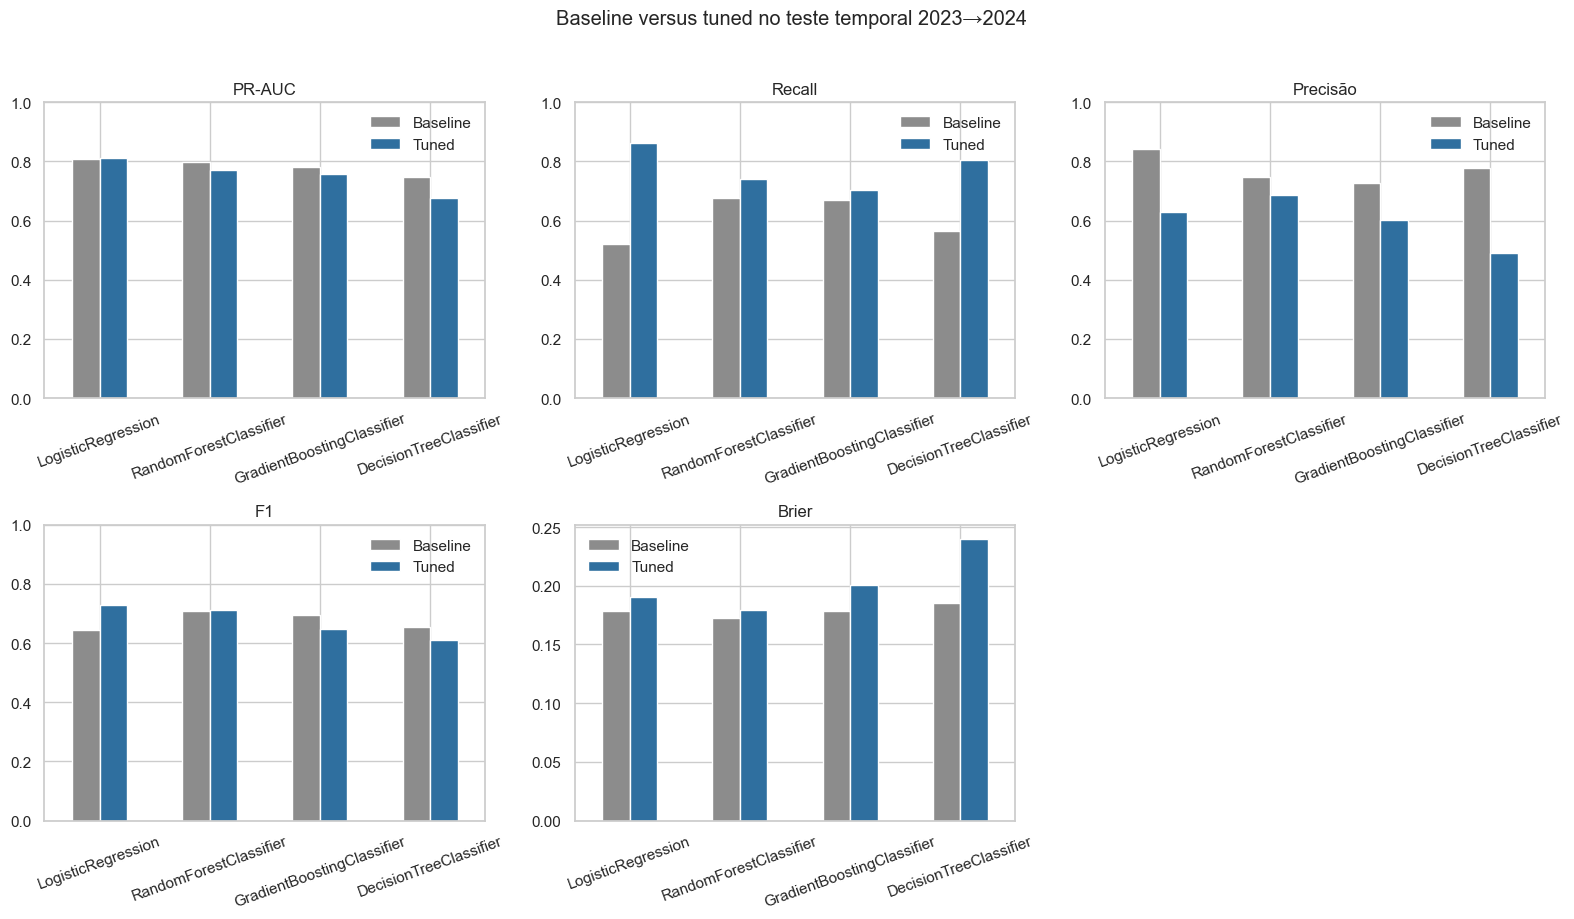

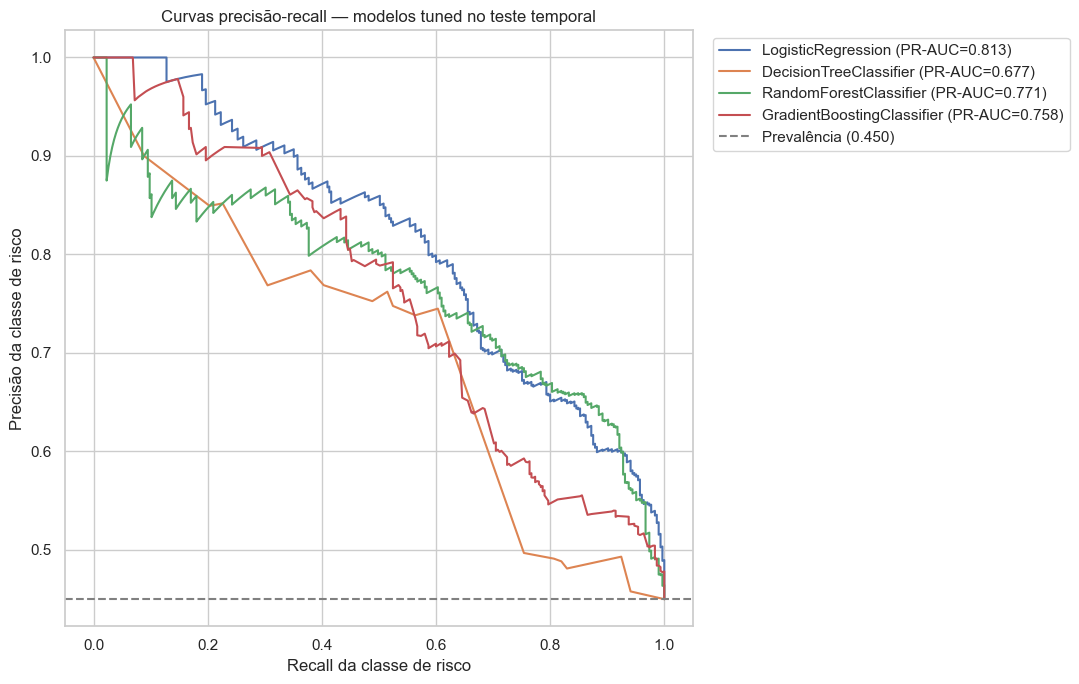

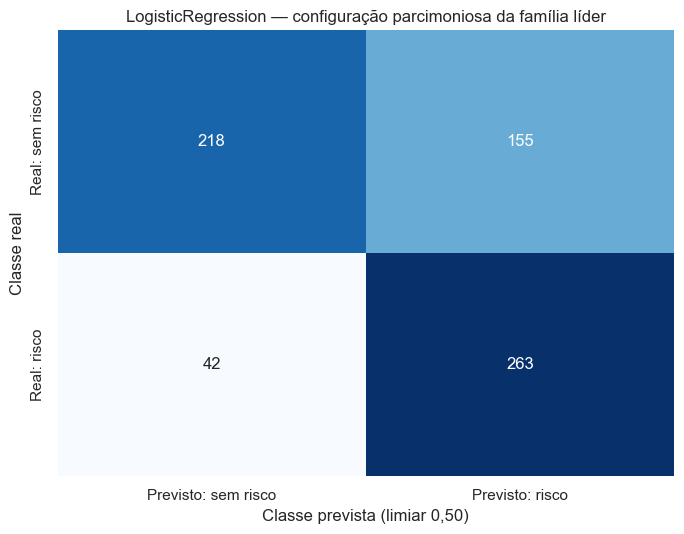

,recall_risco,precision_risco,f1_risco,pr_auc,brier_score,modelo,limiar,verdadeiros_negativos,falsos_positivos,falsos_negativos,verdadeiros_positivos
0,0.862,0.629,0.728,0.813,0.190,LogisticRegression,0.500,218,155,42,263
2,0.741,0.687,0.713,0.771,0.179,RandomForestClassifier,0.500,270,103,79,226
3,0.705,0.601,0.649,0.758,0.201,GradientBoostingClassifier,0.500,230,143,90,215
1,0.807,0.491,0.610,0.677,0.240,DecisionTreeClassifier,0.500,118,255,59,246


,modelo,baseline_pr_auc,tuned_pr_auc,delta_pr_auc,baseline_recall,tuned_recall,delta_recall,baseline_precision,tuned_precision,delta_precision,baseline_f1,tuned_f1,delta_f1,baseline_brier,tuned_brier,delta_brier,baseline_falsos_positivos,tuned_falsos_positivos,delta_falsos_positivos,baseline_falsos_negativos,tuned_falsos_negativos,delta_falsos_negativos,tuned_pr_auc_cv,tuned_desvio_pr_auc_cv,tuned_gap_treino_validacao_pr_auc,delta_pr_auc_teste_menos_cv,aumento_complexidade
0,LogisticRegression,0.809,0.813,0.004,0.521,0.862,0.341,0.841,0.629,-0.212,0.644,0.728,0.084,0.179,0.190,0.011,30,155,125,146,42,-104,0.919,0.013,0.011,-0.107,"configuração ajustada; avaliar parâmetros, estabilidade e gap antes de substituir a referência"
1,RandomForestClassifier,0.800,0.771,-0.029,0.675,0.741,0.066,0.746,0.687,-0.059,0.709,0.713,0.004,0.173,0.179,0.006,70,103,33,99,79,-20,0.868,0.025,0.086,-0.098,"configuração ajustada; avaliar parâmetros, estabilidade e gap antes de substituir a referência"
2,GradientBoostingClassifier,0.781,0.758,-0.023,0.669,0.705,0.036,0.726,0.601,-0.125,0.696,0.649,-0.048,0.178,0.201,0.023,77,143,66,101,90,-11,0.879,0.026,0.040,-0.122,"configuração ajustada; avaliar parâmetros, estabilidade e gap antes de substituir a referência"
3,DecisionTreeClassifier,0.747,0.677,-0.070,0.564,0.807,0.243,0.778,0.491,-0.287,0.654,0.610,-0.044,0.185,0.240,0.055,49,255,206,133,59,-74,0.835,0.039,0.063,-0.159,"configuração ajustada; avaliar parâmetros, estabilidade e gap antes de substituir a referência"



LogisticRegression — matriz de confusão tuned


,Previsto: sem risco,Previsto: risco
Real: sem risco,218,155
Real: risco,42,263



DecisionTreeClassifier — matriz de confusão tuned


,Previsto: sem risco,Previsto: risco
Real: sem risco,118,255
Real: risco,59,246



RandomForestClassifier — matriz de confusão tuned


,Previsto: sem risco,Previsto: risco
Real: sem risco,270,103
Real: risco,79,226



GradientBoostingClassifier — matriz de confusão tuned


,Previsto: sem risco,Previsto: risco
Real: sem risco,230,143
Real: risco,90,215


In [20]:
# Única avaliação dos estimadores tuned no teste temporal, em limiar fixo 0,50.
metricas_tuned, matrizes_tuned, probabilidades_tuned_memoria = (
    avaliar_melhores_no_teste_temporal(
        estimadores_tuned, x_teste, y_teste, limiar=0.50
    )
)
comparacao_baseline_tuned = comparar_baseline_tuned(
    comparacao, matrizes, metricas_tuned, melhores_parametros
)

metricas_tuned.to_csv(
    PASTA_TABELAS / 'model_metrics_tuned.csv', index=False, encoding='utf-8-sig'
)
comparacao_baseline_tuned.to_csv(
    PASTA_TABELAS / 'comparacao_baseline_tuned.csv', index=False, encoding='utf-8-sig'
)

metricas_plot = ['pr_auc', 'recall', 'precision', 'f1', 'brier']
rotulos_plot = ['PR-AUC', 'Recall', 'Precisão', 'F1', 'Brier']
figura, eixos = plt.subplots(2, 3, figsize=(16, 9))
for eixo, metrica, rotulo in zip(eixos.flat, metricas_plot, rotulos_plot):
    dados = comparacao_baseline_tuned.set_index('modelo')[
        [f'baseline_{metrica}', f'tuned_{metrica}']
    ].rename(columns={f'baseline_{metrica}': 'Baseline', f'tuned_{metrica}': 'Tuned'})
    dados.plot(kind='bar', ax=eixo, color=['#8c8c8c', '#2f6f9f'])
    eixo.set_title(rotulo)
    eixo.set_xlabel('')
    eixo.tick_params(axis='x', rotation=20)
    if metrica != 'brier':
        eixo.set_ylim(0, 1)
    eixo.legend(frameon=False)
eixos.flat[-1].axis('off')
figura.suptitle('Baseline versus tuned no teste temporal 2023→2024', y=1.02)
figura.tight_layout()
figura.savefig(PASTA_FIGURAS / 'comparacao_baseline_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

figura, eixo = plt.subplots(figsize=(11, 7))
for nome, probabilidades in probabilidades_tuned_memoria.items():
    precisao_curva, recall_curva, _ = precision_recall_curve(y_teste, probabilidades)
    pr_auc_teste = average_precision_score(y_teste, probabilidades)
    eixo.plot(recall_curva, precisao_curva, label=f'{nome} (PR-AUC={pr_auc_teste:.3f})')
eixo.axhline(y_teste.mean(), color='gray', linestyle='--', label=f'Prevalência ({y_teste.mean():.3f})')
eixo.set_xlabel('Recall da classe de risco')
eixo.set_ylabel('Precisão da classe de risco')
eixo.set_title('Curvas precisão-recall — modelos tuned no teste temporal')
eixo.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
figura.tight_layout()
figura.savefig(PASTA_FIGURAS / 'curva_precision_recall_modelos_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

familia_lider = melhores_parametros.sort_values(
    ['media_cv_pr_auc', 'desvio_cv_pr_auc'], ascending=[False, True]
).iloc[0]['modelo']
matriz_lider_tuned = matrizes_tuned[familia_lider]
figura, eixo = plt.subplots(figsize=(7, 5.5))
sns.heatmap(matriz_lider_tuned, annot=True, fmt='d', cmap='Blues', cbar=False, ax=eixo)
eixo.set_title(f'{familia_lider} — configuração parcimoniosa da família líder')
eixo.set_xlabel('Classe prevista (limiar 0,50)')
eixo.set_ylabel('Classe real')
figura.tight_layout()
figura.savefig(PASTA_FIGURAS / 'matriz_confusao_melhor_modelo_tuned.png', dpi=300, bbox_inches='tight')
plt.show()

# Probabilidades permanecem somente em memória e não são exportadas.
display(metricas_tuned.style.format(precision=3))
display(comparacao_baseline_tuned.style.format(precision=3))
for nome, matriz in matrizes_tuned.items():
    print(f'\n{nome} — matriz de confusão tuned')
    display(matriz)

### 18.4. Interpretação, sobreajuste e limitações da otimização

Os sinais de sobreajuste são avaliados pela diferença entre PR-AUC de treino e validação, pela dispersão entre folds e pela diferença entre CV e teste. Com 1.004 comparações sobre apenas 570 linhas e uma única transição de treino, a configuração vencedora pode refletir variação amostral. Uma melhoria pequena ou instável não justifica substituir o baseline. PR-AUC também não garante melhor calibração ou melhor ponto operacional.

Há **434 estudantes nas duas janelas**. Nenhuma linha do teste entra no Grid Search e não há duplicidade de RA dentro dos folds do treino, mas a avaliação mede generalização temporal parcialmente sobre estudantes observados em ciclo anterior. Ela não representa exclusivamente estudantes novos. Os **244 estudantes do teste não observados no treino** permanecem importantes para a análise de sensibilidade anterior.

A leitura do efeito dos pesos deve considerar que `balanced` reduz o peso relativo da classe 1 neste treino, enquanto os dicionários aumentam deliberadamente seu custo. Ganhos de recall precisam ser confrontados com precision, Brier, falsos positivos, falsos negativos e estabilidade. Como o teste foi consultado somente após a seleção, ele serve para auditoria temporal, não para reabrir a otimização.

A recomendação técnica abaixo deve ser interpretada como decisão de continuidade de pesquisa. Ela não altera automaticamente o Random Forest atual e não aprova uso operacional.

### 18.5. Resultado executado e recomendação técnica

O **líder técnico da validação interna** foi a Regressão Logística bruta com `C=100`, solver `liblinear` e peso `{0: 1, 1: 3.0}` (PR-AUC média 0,930 ± 0,020). Aplicando a regra de parcimônia, a configuração selecionada da família foi `C=1`, solver `lbfgs` e o mesmo peso, com PR-AUC 0,919 ± 0,013 e gap treino–validação 0,011. Essa escolha teve PR-AUC temporal 0,813, praticamente igual ao baseline da família (+0,004), e aumentou recall de 0,521 para 0,862 e F1 de 0,644 para 0,728. A contrapartida foi queda de precision de 0,841 para 0,629, aumento de falsos positivos de 30 para 155 e piora do Brier de 0,179 para 0,190.

O Random Forest tuned parcimonioso usou 300 árvores, profundidade 6, `max_features=0.7`, `min_samples_leaf=10`, `min_samples_split=10` e `class_weight=None`. No teste, elevou recall em 0,066 e reduziu falsos negativos de 99 para 79, porém perdeu 0,029 de PR-AUC, perdeu 0,059 de precision, acrescentou 33 falsos positivos, praticamente não alterou F1 (+0,004) e piorou o Brier em 0,006. Seu gap treino–validação de PR-AUC foi 0,086 e a queda CV→teste foi 0,098, sinais de generalização temporal insuficiente.

Gradient Boosting e Árvore de Decisão tuned também não demonstraram ganho consistente: ambos perderam PR-AUC, F1 e Brier no teste apesar do aumento de recall. As diferenças CV→teste foram −0,122 e −0,159, respectivamente.

**Recomendação:** concluir que o Grid Search **não produziu ganho consistente suficiente para alterar a referência atual** e manter o Random Forest baseline como candidato de continuidade, sem promovê-lo a modelo final. A Regressão Logística tuned merece análise futura como cenário de alta sensibilidade, mas seu custo de 125 falsos positivos adicionais e a piora de calibração impedem substituição automática. Uma decisão posterior exige custos operacionais explícitos, novas safras, calibração e validação externa; o teste desta execução não será reutilizado para ajustar parâmetros, pesos ou limiar.